# RAG local para sessão de perguntas e resposta sobre o cardápio de hoje

- Usa OCR (Tesseract) para extrair informações de um cardápio na forma de imagem (PNG)
- Realiza o parsing das informações extraídas usando uma LLM
- Exporta as informações estruturadas com CSV e JSON


## Configurações inicias

### Define constantes

In [ ]:
EXPORT_PARSED_OCR = True

# image input 
img_path = 'input_imgs/cardapio-hoje.png'

# output path
json_path = 'outputs_json/cardapio-hoje-infos-extracted.json'

### Carrega bibliotecas

In [3]:
import json
import os
import re
from rich import print
from dotenv import load_dotenv

import pandas as pd
import cv2
import pytesseract
import matplotlib.pyplot as plt

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq

load_dotenv()

True

### Visualiza imagem do cardápio

In [4]:
def show_img(img_path: str) -> None:
    # show the image of img_path
    menu_img = cv2.imread(img_path)
    menu_img = cv2.cvtColor(menu_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20, 10))
    plt.imshow(menu_img)
    plt.axis('off')
    plt.show()

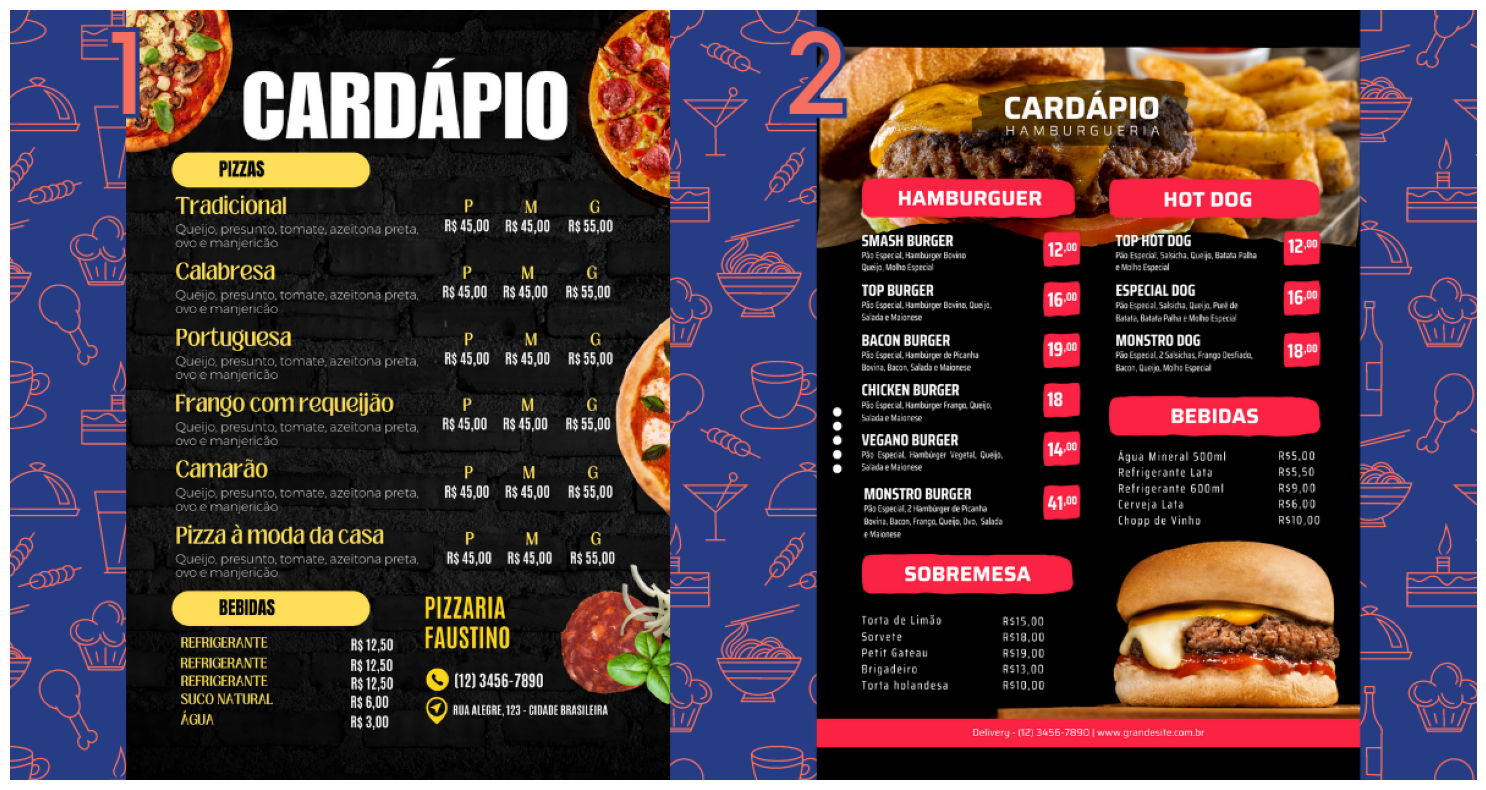

In [5]:
show_img(img_path=img_path)

## Realiza OCR

### Extração com Tesseract

In [6]:
def extract_text_from_image(img_path: str) -> str:
    '''
    Extract raw text from an image using Tesseract OCR.

    Args:
        img_path: Path to the image file.

    Returns:
        text: Raw text extracted from the image.
    '''

    img = cv2.imread(img_path)

    height, width, channels = img.shape
    scale_percent = 250
    new_dim = (int(width*scale_percent/100), int(height*scale_percent/100))
    resized = cv2.resize(img, new_dim, interpolation=cv2.INTER_LINEAR)
    text = pytesseract.image_to_string(resized, config='--psm 6 --oem 3')
    
    return text

In [7]:
ocr_text = extract_text_from_image(img_path)
print(f'[white on blue]{ocr_text}[/white on blue]')

SO =e Ri <9 n ye
b ' wy 2 - ~
iE y - Oe ' y _— im
ae ef oan z > Wars
aN a ARDAPI (be CARDAPIO ae
NS Be | HAMBURGUER PA! stem -
hs bn «, eee ,
/_) ap ONE ae SO d
Tradicional pila 6 4 e . 4 saree
= Que ©, presunto, tomate, azeitona preta. R$ 45,00 RS 45,00 As 55,00 .
Cc » agin nsn: a rm | SMASH BURGER OP HOT DOG “ j
SS Pap Exper ed, Hamburger Bevin Pao Especia!, Sabskcha, Guaje, Batata Falke
\\ | tf Calabresa P M G Queija, Mahe Eszecial e Maths Especial
Queljo, presunto, tomate, azeitona preta, 845,00 R$.45,00 A$ 55,00 >) TOP BURGER ESPECIAL DOG >)
woe maniericSo ») ( Ps Especial, Hamburger Bevino, Que ja Pao Especial, Salsicha, Qurija. und de @ >
nN Salada e Maiorese Batste, Batete Paha © Mole Esceve! SS
Portuguesa P M G / BACON BURGER 198 MONSTRO DOG 180
/ Queijo presunto, tomate, azeitona preta, — R45,00 $4500 $5,00 Petpet tog de amar arene aaa
a CHICKEN BURGER
= Frango com requeijao P M G > gq 89eca Hanbrge Han eo
Queijo, presunto, tomate, azeitona preta R$ 45,00 RS 45,00 A$ 55,00 y . panei ~
ovo e maniericso @ VEGANO BURGER —
i a Ce tJ Pao Espeoal. Hambdrger Vegetal Quai. wa Aqua Mineral 500ml R$5,00
Camardao P M G ; @ Meee Refrigerante Lata R55,50
) Queijo, presunto, tomate, azeitona preta, AG-45,00 R$ 45,00 A$ 55,00 MONSTRO BURGER we Refrigerante 600ml RS9,00 
—
ove. € manjenicao Pao Especel, 2 Hamburger de Picatha Cerveja Lata RS6,00
% id Bovina, Bacon, Frango, Queija, Ovo, Salada Chopp de Vinho R$10,00
| Pizza a moda da casa P M G ) evens A.
Queijo. presunto, tomate, azeitona preta, $45,000 RS45,00 A$ 55,00 :
a
= 5 BEBIDAS PIZZARIA > sorte de Limo ais. o0 —
CAN REFRIGERANTE asso FAUSTINO “~ Sorvete 518,00 bicere Hh’ VY
\\ | 1) Raters ‘ 7 > ey = Petit Gateau 8$19,00 =
REFRIGERANTE A$ 12,50 * Brigadeiro A$13,00 - 5
REFRIGERANTE RS 12.50 @ (12) 3456-7890 = Ws ( Torta holandesa A$10,00 = >
ye Rs 6,00 @ AUA ALEGRE, 123 - CIDADE BRASILEIRA _ So \
AGUA Rg 3,00 l1/ =

### Parsing com LLM

In [ ]:
if EXPORT_PARSED_OCR:
    chat = ChatGroq(
        model='llama-3.3-70b-versatile',
        temperature=0,
        max_tokens=None,
        timeout=None,
        max_retries=2,
    )

In [9]:
if EXPORT_PARSED_OCR:
    def call_llm(content: str) -> str:
        '''
        Use a LLM model to parse input text and returns the fields extracted.
        '''

        system_prompt = f'''
            You are a document extraction agent.

            Extract the information below from the text and return the valid JSON with *all* items. Not add extra comments.
            For pizza items we can have a price value depending of your size: P, M, or G. Add one field for each of them.

            Fields:
                - item name
                - price
                - description

            Text:
            {content}
        '''

        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=ocr_text)
        ]
        
        llm_response = chat.invoke(messages)
        
        raw_text = llm_response.content
        clean_text = re.sub(r'```json|```', '', raw_text).strip()
        data = json.loads(clean_text)

        # export output as JSON and CSV
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f'\nSaved as JSON: {json_path}')

        df_res = pd.DataFrame(data)
        csv_path = json_path.replace('.json', '.csv')
        df_res.to_csv(csv_path, index=False, encoding='utf-8')
        print(f'\nSaved as CSV: {csv_path}')

        return data

    # make parsing with lllm
    llm_output = call_llm(ocr_text)
    print(llm_output)

Saved as JSON: outputs_json/cardapio-hoje-infos-extracted.json

Saved as CSV: outputs_json/cardapio-hoje-infos-extracted.csv

[
    {
        'item_name': 'Tradicional',
        'price_P': 45.0,
        'price_M': 45.0,
        'price_G': 55.0,
        'description': 'Queijo, presunto, tomate, azeitona preta'
    },
    {
        'item_name': 'SMASH BURGER',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': 'Hamburger Bevin Pao Especial, Sabskcha, Guaje, Batata Falke'
    },
    {
        'item_name': 'Calabresa',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': 'Queija, Mahe Eszecial e Maths Especial'
    },
    {
        'item_name': 'TOP BURGER',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': 'Hamburger Bevino, Que ja Pao Especial, Salsicha, Qurija'
    },
    {
        'item_name': 'Portuguesa',
        'price_P': 45.0,
        'price_M': 45.0,
        'price_G': 55.0,
        'description': 'Queijo presunto, tomate, azeitona preta'
    },
    {
        'item_name': 'CHICKEN BURGER',
        'price_P': 45.0,
        'price_M': 45.0,
        'price_G': 55.0,
        'description': 'Frango com requeijao, Queijo, presunto, tomate, azeitona preta'
    },
    {
        'item_name': 'VEGANO BURGER',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': 'Pao Especial, Hambdrger Vegetal Quai'
    },
    {
        'item_name': 'Camardao',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': 'Queijo, presunto, tomate, azeitona preta'
    },
    {
        'item_name': 'MONSTRO BURGER',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': '2 Hamburger de Picatha'
    },
    {
        'item_name': 'Pizza a moda da casa',
        'price_P': 45.0,
        'price_M': 45.0,
        'price_G': 55.0,
        'description': 'Queijo, presunto, tomate, azeitona preta'
    },
    {
        'item_name': 'Refrigerante',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 5.5
    },
    {
        'item_name': 'Aqua Mineral',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 5.0
    },
    {
        'item_name': 'Cerveja Lata',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 6.0
    },
    {
        'item_name': 'Chopp de Vinho',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 10.0
    },
    {
        'item_name': 'Sorvete',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 18.0
    },
    {
        'item_name': 'Petit Gateau',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 19.0
    },
    {
        'item_name': 'Brigadeiro',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 13.0
    },
    {
        'item_name': 'Torta holandesa',
        'price_P': None,
        'price_M': None,
        'price_G': None,
        'description': None,
        'price': 10.0
    },
    {'item_name': 'AGUA', 'price_P': None, 'price_M': None, 'price_G': None, 'description': None, 'price': 3.0}
]

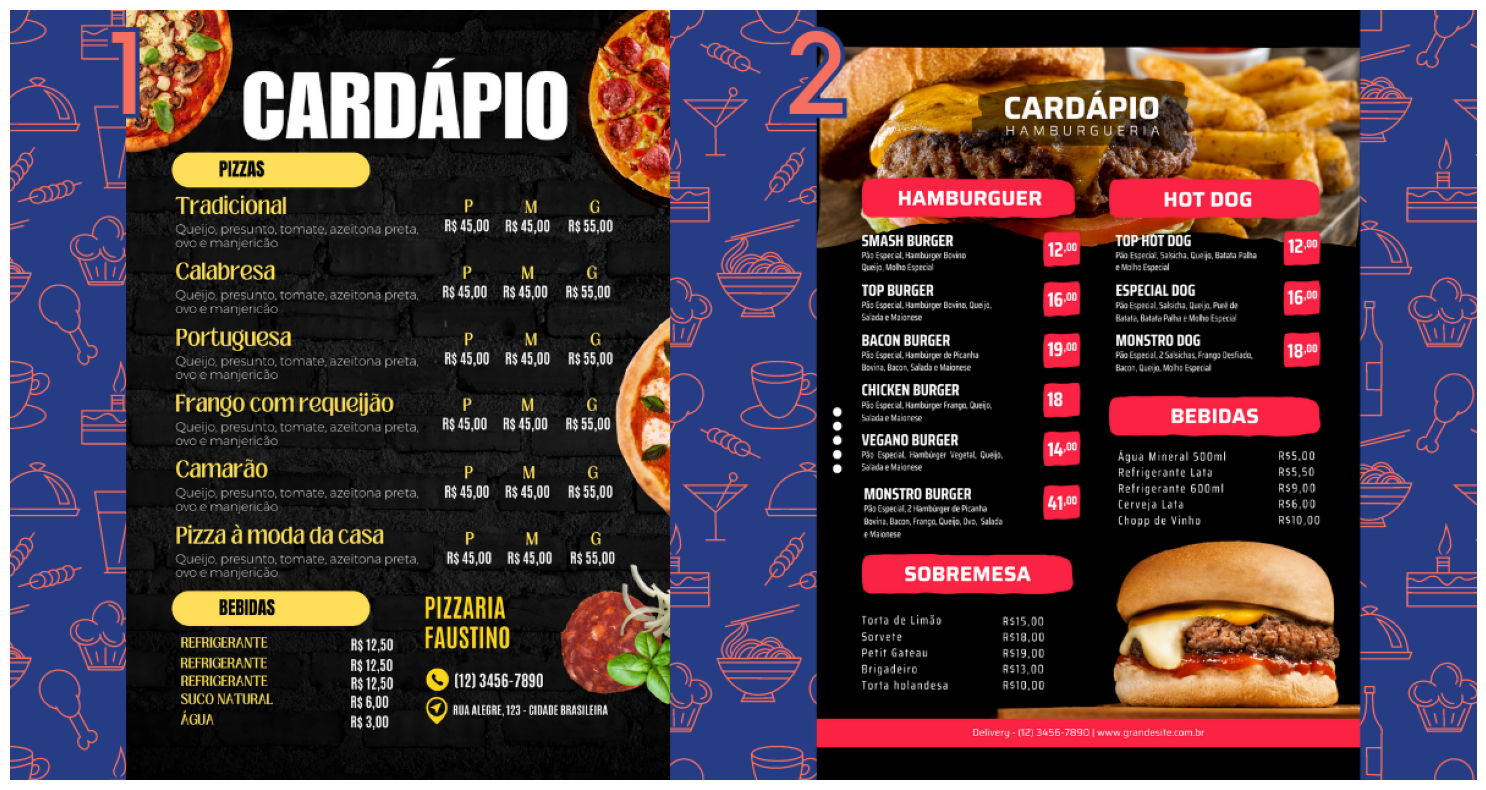

In [10]:
show_img(img_path=img_path)